# 09 Technology Change and Scale Heterogeneity

This notebook handles Subagent 09's annual technology-change and scale-heterogeneity analysis. Inputs are restricted to the new master dataset and keyword table:

- `data/NSFC正式增量采集_2014-2026_去重筛选最终结果.csv`
- `data/NSFC正式增量采集_37个关键词.csv`

Outputs are restricted to:

- `output/figures/Fig8_annual_method_changes.svg/pdf/tiff/png`
- `output/figures/Fig9_scale_heterogeneity.svg/pdf/tiff/png`
- `output/tables/09_annual_method_changes.csv`
- `output/tables/09_scale_heterogeneity.csv`
- `output/logs/09_method_scale_text.md`

Note: code comments and human-facing text are in English, and all visible figure text is English. Classification results are inferred from project titles, abstracts, keywords, matched terms in the master dataset, and textual signals in the keyword table; they are not equivalent to manual full-text coding record by record.



## Figure contract

- Core conclusion: The reviewed project records show a shift in sensing sources, analytical methods and performance targets over time, while these choices vary across building, street, block, city, urban-agglomeration and regional scales.
- Evidence chain: Fig. 8 compares annual shares for primary data sources, analytical methods and performance targets; Fig. 9 compares scale-specific source and target compositions.
- Archetype: quantitative grid.
- Backend: Python / matplotlib only.
- Export contract: editable SVG/PDF, high-resolution TIFF/PNG, and source tables saved as CSV.


In [1]:
# ===== 1. Environment Setup and Path Configuration =====
# This notebook only reads the new master dataset and keyword table; it does not write back to the data directory.
# All figures, tables, and logs are written to the 09/Fig8/Fig9 files assigned to this subagent.

from pathlib import Path
from collections import OrderedDict
import re
import textwrap

import numpy as np
import pandas as pd
import matplotlib as mpl
from matplotlib import font_manager
import matplotlib.pyplot as plt

# Register and require Times New Roman; stop immediately if the font is unavailable instead of using a substitute.
TIMES_NEW_ROMAN_PATHS = [
    Path("/Library/Fonts/Times New Roman.ttf"),
    Path("/Library/Fonts/Times New Roman Bold.ttf"),
    Path("/Library/Fonts/Times New Roman Italic.ttf"),
    Path("/Library/Fonts/Times New Roman Bold Italic.ttf"),
    Path("/System/Library/Fonts/Supplemental/Times New Roman.ttf"),
    Path("/System/Library/Fonts/Supplemental/Times New Roman Bold.ttf"),
    Path("/System/Library/Fonts/Supplemental/Times New Roman Italic.ttf"),
    Path("/System/Library/Fonts/Supplemental/Times New Roman Bold Italic.ttf"),
]
for font_path in TIMES_NEW_ROMAN_PATHS:
    if font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
try:
    font_manager.findfont("Times New Roman", fallback_to_default=False)
except ValueError as exc:
    raise RuntimeError("Times New Roman is required for figure export but was not found by matplotlib.") from exc

import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown

MAIN_DATA_FILENAME = "NSFC正式增量采集_2014-2026_去重筛选最终结果.csv"
KEYWORD_TABLE_FILENAME = "NSFC正式增量采集_37个关键词.csv"
EXPECTED_MAIN_N = 9222
EXPECTED_KEYWORD_N = 37
YEAR_START = 2010
YEAR_END = 2023


def find_project_root(start=None):
    """Find the project root upward from the current directory so runs are reproducible from the root or code directory."""
    start_path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start_path, *start_path.parents]:
        data_dir = candidate / "data"
        if (data_dir / MAIN_DATA_FILENAME).exists() and (data_dir / KEYWORD_TABLE_FILENAME).exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the new master dataset and keyword table in the current directory or its parents."
    )


ROOT = find_project_root()
DATA_PATH = ROOT / "data" / MAIN_DATA_FILENAME
KEYWORD_TABLE_PATH = ROOT / "data" / KEYWORD_TABLE_FILENAME
FIGURE_DIR = ROOT / "output" / "figures"
TABLE_DIR = ROOT / "output" / "tables"
LOG_DIR = ROOT / "output" / "logs"

FIG8_BASE = FIGURE_DIR / "Fig8_annual_method_changes"
FIG9_BASE = FIGURE_DIR / "Fig9_scale_heterogeneity"
ANNUAL_TABLE_PATH = TABLE_DIR / "09_annual_method_changes.csv"
SCALE_TABLE_PATH = TABLE_DIR / "09_scale_heterogeneity.csv"
LOG_PATH = LOG_DIR / "09_method_scale_text.md"

# Create only the allowed output directories so later Fig8/Fig9/table/log workers can rerun export cells directly.
for directory in [FIGURE_DIR, TABLE_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Input data: {DATA_PATH}")
print(f"Keyword table: {KEYWORD_TABLE_PATH}")


Project root: /Volumes/ZHITAI2T/202607综述BAE
Input data: /Volumes/ZHITAI2T/202607综述BAE/data/NSFC正式增量采集_2014-2026_去重筛选最终结果.csv
Keyword table: /Volumes/ZHITAI2T/202607综述BAE/data/NSFC正式增量采集_37个关键词.csv


In [2]:
# ===== 2. Load the Master Dataset and Keyword Table, Then Run Minimal Field Checks =====
# Use a numeric copy of award_year for grouping while preserving the original field; the annual axis is fixed to the full 2010-2023 range.

keyword_table = pd.read_csv(KEYWORD_TABLE_PATH)
required_keyword_columns = {"term", "term_group"}
missing_keyword_columns = sorted(required_keyword_columns.difference(keyword_table.columns))
if missing_keyword_columns:
    raise KeyError(f"Keyword table is missing required columns: {missing_keyword_columns}")

keyword_table = keyword_table.loc[:, ["term", "term_group"]].copy()
keyword_table["term"] = keyword_table["term"].astype("string").str.strip()
keyword_table["term_group"] = keyword_table["term_group"].astype("string").str.strip()
if keyword_table[["term", "term_group"]].isna().any().any() or keyword_table["term"].eq("").any():
    raise ValueError("Keyword table contains empty term or term_group values.")
if len(keyword_table) != EXPECTED_KEYWORD_N:
    raise ValueError(f"Keyword table should contain {EXPECTED_KEYWORD_N} terms; found {len(keyword_table)}.")
if keyword_table["term"].duplicated().any():
    duplicated_terms = keyword_table.loc[keyword_table["term"].duplicated(), "term"].tolist()
    raise ValueError(f"Keyword table contains duplicate terms: {duplicated_terms}")

KEYWORD_TERMS_BY_GROUP = keyword_table.groupby("term_group")["term"].apply(lambda terms: set(terms)).to_dict()
KEYWORD_TERMS = set(keyword_table["term"])
expected_keyword_groups = {"method", "object_built_environment", "performance_environment"}
missing_keyword_groups = sorted(expected_keyword_groups.difference(KEYWORD_TERMS_BY_GROUP))
if missing_keyword_groups:
    raise ValueError(f"Keyword table is missing required term_group values: {missing_keyword_groups}")

df = pd.read_csv(DATA_PATH, dtype={"award_id": "string", "dedup_key": "string"}, low_memory=False)
if len(df) != EXPECTED_MAIN_N:
    raise ValueError(f"New master dataset should have N={EXPECTED_MAIN_N}; found N={len(df)}.")

required_columns = {
    "award_id",
    "award_year",
    "project_title",
    "abstract_text",
    "keywords_raw",
    "matched_keywords",
    "matched_method_terms",
    "matched_object_terms",
    "matched_performance_terms",
    "knowledge_prod_place",
    "research_object_place",
    "beneficiary_city",
}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise KeyError(f"Master dataset is missing required columns: {missing_columns}")

classified = df.copy()
classified["award_year_num"] = pd.to_numeric(classified["award_year"], errors="coerce").astype("Int64")
if classified["award_year_num"].isna().any():
    bad_rows = classified.loc[classified["award_year_num"].isna(), ["award_id", "award_year", "project_title"]]
    raise ValueError(f"Some award_year values could not be parsed:\n{bad_rows}")

YEAR_AXIS = list(range(YEAR_START, YEAR_END + 1))
outside_year_mask = ~classified["award_year_num"].between(YEAR_START, YEAR_END)
if outside_year_mask.any():
    outside_years = sorted(classified.loc[outside_year_mask, "award_year_num"].astype(int).unique().tolist())
    raise ValueError(f"Master dataset contains award_year values outside 2010-2023: {outside_years}")

place_columns = ["knowledge_prod_place", "research_object_place", "beneficiary_city"]
place_non_null = {col: int(classified[col].notna().sum()) for col in place_columns}

print(f"Rows: {len(classified)}")
print(f"Year axis: {YEAR_AXIS[0]}-{YEAR_AXIS[-1]} ({len(YEAR_AXIS)} years)")
print(f"Keyword terms: {len(keyword_table)}")
print("Structured place fields with non-null values:", place_non_null)


Rows: 9222
Year axis: 2010-2023 (14 years)
Keyword terms: 37
Structured place fields with non-null values: {'knowledge_prod_place': 0, 'research_object_place': 0, 'beneficiary_city': 0}


In [3]:
# ===== 3. Classification Vocabularies and Primary-Category Rules =====
# Annual 100% stacked bars require each record to enter only one primary category per dimension.
# Therefore, the primary-category rules prioritize specificity and validate all method/performance classification terms against the 37-term keyword table.

TEXT_FOR_SCALE = ["project_title", "abstract_text", "keywords_raw", "matched_object_terms"]


def keyword_terms(group, *values):
    """Return terms from the requested keyword-table group; fail immediately if a rule uses out-of-table terms."""
    allowed_terms = KEYWORD_TERMS_BY_GROUP[group]
    missing_terms = sorted(set(values).difference(allowed_terms))
    if missing_terms:
        raise ValueError(f"Classification rules use terms outside keyword-table group {group}: {missing_terms}")
    return list(values)


DATA_SOURCE_SPECS = OrderedDict([
    ("Street-level/POI data", keyword_terms("method", "街景", "POI")),
    ("Mobility/location traces", keyword_terms("method", "手机信令", "轨迹", "LBS")),
    ("3D/LiDAR data", keyword_terms("method", "三维", "LiDAR")),
    ("Night-time lights", keyword_terms("method", "夜间灯光")),
    ("Satellite/aerial imagery", keyword_terms("method", "遥感", "高分")),
    ("Geospatial/GIS databases", keyword_terms("method", "GIS", "地理信息")),
    ("Urban big data", keyword_terms("method", "多源数据", "大数据")),
    ("Other/unspecified", []),
])

METHOD_SPECS = OrderedDict([
    ("Machine/deep learning and AI", keyword_terms("method", "机器学习", "深度学习", "人工智能")),
    ("3D modelling and simulation", keyword_terms("method", "三维", "LiDAR")),
    ("Mobility/activity mining", keyword_terms("method", "轨迹", "手机信令", "LBS", "POI")),
    ("Multi-source data fusion", keyword_terms("method", "多源数据", "大数据")),
    ("Spatial analysis/GIS modelling", keyword_terms("method", "GIS", "地理信息")),
    ("Remote-sensing retrieval", keyword_terms("method", "遥感", "高分", "夜间灯光")),
    ("Other/unspecified", []),
])

PERFORMANCE_TERM_SETS = {
    "heat": set(keyword_terms("performance_environment", "热岛", "热环境")),
    "flood_resilience": set(keyword_terms("performance_environment", "洪涝", "韧性")),
    "carbon_energy": set(keyword_terms("performance_environment", "碳", "能源")),
    "air_exposure": set(keyword_terms("performance_environment", "空气污染", "暴露")),
    "ecology": set(keyword_terms("performance_environment", "生态环境")),
    "climate": set(keyword_terms("performance_environment", "气候")),
}

# For performance targets, climate is a broad term; heat-island and thermal-environment terms are assigned to Urban climate and heat first,
# while more specific flooding/resilience, carbon/energy, air/exposure, and ecological-quality terms are checked before the broad climate fallback.
PERFORMANCE_ORDER = [
    "Urban climate and heat",
    "Flooding and resilience",
    "Carbon and energy",
    "Air quality and exposure",
    "Ecological quality",
    "Not performance-specific",
]

SCALE_KEYWORD_PRIORITY = OrderedDict([
    ("Building", set(keyword_terms("object_built_environment", "建筑"))),
    ("Street", set(keyword_terms("object_built_environment", "街道"))),
    ("Block", set(keyword_terms("object_built_environment", "街区"))),
    ("Urban agglomeration", set(keyword_terms("object_built_environment", "城市群"))),
])

SCALE_SPECS = OrderedDict([
    ("Building", [r"建筑", r"楼宇", r"建筑物", r"建筑能耗", r"building"]),
    ("Street", [r"街道", r"街景", r"道路", r"路网", r"街谷", r"street", r"road"]),
    ("Block", [r"街区", r"社区", r"居住区", r"小区", r"邻里", r"片区", r"block", r"neighbou?rhood", r"residential"]),
    ("Urban agglomeration", [r"城市群", r"都市圈", r"都市区", r"大都市区", r"urban agglomeration", r"metropolitan"]),
    ("Regional", [r"关键区域", r"典型区域", r"区域协同", r"区域合作", r"区域空间", r"多区域", r"跨区域", r"省域", r"流域", r"京津冀", r"长三角", r"珠三角", r"黄河流域", r"长江经济带", r"成渝", r"北部湾", r"中原", r"全国", r"中国", r"regional", r"region"]),
    ("City", [r"城市", r"城镇", r"urban", r"city", r"市域", r"城区", r"建成区"]),
    ("Not specified", []),
])


def split_terms(value):
    """Split semicolon-delimited matched terms into a stripped set."""
    if pd.isna(value):
        return set()
    return {
        term.strip()
        for term in str(value).replace("；", ";").split(";")
        if term.strip() and term.strip().lower() != "nan"
    }


def collapse_by_priority(term_value, specs):
    """Return the first matched primary category in OrderedDict order; otherwise return the final fallback category."""
    terms = split_terms(term_value)
    for category, keywords in specs.items():
        if keywords and any(keyword in terms for keyword in keywords):
            return category
    return next(reversed(specs))


def classify_performance(term_value):
    """Assign one primary performance category by priority to avoid double-counting records in 100% charts."""
    terms = split_terms(term_value)
    if PERFORMANCE_TERM_SETS["heat"].intersection(terms):
        return "Urban climate and heat"
    if PERFORMANCE_TERM_SETS["flood_resilience"].intersection(terms):
        return "Flooding and resilience"
    if PERFORMANCE_TERM_SETS["carbon_energy"].intersection(terms):
        return "Carbon and energy"
    if PERFORMANCE_TERM_SETS["air_exposure"].intersection(terms):
        return "Air quality and exposure"
    if PERFORMANCE_TERM_SETS["ecology"].intersection(terms):
        return "Ecological quality"
    if PERFORMANCE_TERM_SETS["climate"].intersection(terms):
        return "Urban climate and heat"
    return "Not performance-specific"


def join_text_fields(row, columns):
    """Join title, abstract, and keywords into scale-detection text; omit outcomes_text to reduce incidental hits in long output text."""
    parts = []
    for column in columns:
        value = row.get(column, "")
        if pd.notna(value):
            parts.append(str(value))
    return " ".join(parts).lower()


def classify_scale(row):
    """Identify the primary scale from matched object terms and text cues; multi-scale projects prioritize higher spatial resolution."""
    object_terms = split_terms(row.get("matched_object_terms", ""))
    for scale, terms in SCALE_KEYWORD_PRIORITY.items():
        if terms.intersection(object_terms):
            return scale

    text = join_text_fields(row, TEXT_FOR_SCALE)
    for scale, patterns in SCALE_SPECS.items():
        if not patterns:
            continue
        for pattern in patterns:
            if re.search(pattern, text, flags=re.IGNORECASE):
                return scale
    return "Not specified"


classified["primary_data_source"] = classified["matched_method_terms"].map(lambda value: collapse_by_priority(value, DATA_SOURCE_SPECS))
classified["primary_method"] = classified["matched_method_terms"].map(lambda value: collapse_by_priority(value, METHOD_SPECS))
classified["primary_performance"] = classified["matched_performance_terms"].map(classify_performance)
classified["primary_scale"] = classified.apply(classify_scale, axis=1)

# Quick classification profile for reviewing whether primary categories match expectations.
for column in ["primary_data_source", "primary_method", "primary_performance", "primary_scale"]:
    print(f"\n{column}")
    print(classified[column].value_counts().reindex(
        list(DATA_SOURCE_SPECS) if column == "primary_data_source" else
        list(METHOD_SPECS) if column == "primary_method" else
        PERFORMANCE_ORDER if column == "primary_performance" else
        list(SCALE_SPECS)
    ).fillna(0).astype(int).to_string())



primary_data_source
primary_data_source
Street-level/POI data       1115
Mobility/location traces     696
3D/LiDAR data               2388
Night-time lights             39
Satellite/aerial imagery    2993
Geospatial/GIS databases     939
Urban big data               533
Other/unspecified            519

primary_method
primary_method
Machine/deep learning and AI      1942
3D modelling and simulation       2504
Mobility/activity mining           908
Multi-source data fusion           598
Spatial analysis/GIS modelling    1188
Remote-sensing retrieval          2077
Other/unspecified                    5

primary_performance
primary_performance
Urban climate and heat      1371
Flooding and resilience      522
Carbon and energy           4011
Air quality and exposure     427
Ecological quality           498
Not performance-specific    2393

primary_scale
primary_scale
Building               1316
Street                  205
Block                   110
Urban agglomeration     223
Regional   

In [4]:
# ===== 4. Build the Annual Technology-Change Table =====
# Within each year-dimension pair, percentages use that year's record count as the denominator; the annual axis keeps all observed records for 2010-2023.

year_counts = classified["award_year_num"].value_counts().reindex(YEAR_AXIS, fill_value=0).astype(int)
if int(year_counts.sum()) != len(classified):
    raise ValueError("Annual counts do not match the master-data N; check the award_year axis.")

ANNUAL_DIMENSIONS = OrderedDict([
    ("Data sources", ("primary_data_source", list(DATA_SOURCE_SPECS))),
    ("Analytical methods", ("primary_method", list(METHOD_SPECS))),
    ("Performance targets", ("primary_performance", PERFORMANCE_ORDER)),
])

annual_rows = []
for dimension_order, (dimension, (column, categories)) in enumerate(ANNUAL_DIMENSIONS.items(), start=1):
    for year in YEAR_AXIS:
        year_mask = classified["award_year_num"].eq(year)
        year_n = int(year_counts.loc[year])
        for category_order, category in enumerate(categories, start=1):
            n_records = int((year_mask & classified[column].eq(category)).sum())
            percent = (n_records / year_n * 100) if year_n else 0.0
            annual_rows.append({
                "award_year": year,
                "dimension_order": dimension_order,
                "dimension": dimension,
                "category_order": category_order,
                "category": category,
                "n_records": n_records,
                "year_n": year_n,
                "percent_within_year": percent,
            })

annual_table = pd.DataFrame(annual_rows)
annual_table.to_csv(ANNUAL_TABLE_PATH, index=False, encoding="utf-8-sig")

print(f"Saved annual table: {ANNUAL_TABLE_PATH}")
display(annual_table.head(12))


Saved annual table: /Volumes/ZHITAI2T/202607综述BAE/output/tables/09_annual_method_changes.csv


,award_year,dimension_order,dimension,category_order,category,n_records,year_n,percent_within_year
0,2010,1,Data sources,1,Street-level/POI data,3,20,15.000000
1,2010,1,Data sources,2,Mobility/location traces,1,20,5.000000
2,2010,1,Data sources,3,3D/LiDAR data,2,20,10.000000
3,2010,1,Data sources,4,Night-time lights,0,20,0.000000
4,2010,1,Data sources,5,Satellite/aerial imagery,13,20,65.000000
5,2010,1,Data sources,6,Geospatial/GIS databases,1,20,5.000000
6,2010,1,Data sources,7,Urban big data,0,20,0.000000
7,2010,1,Data sources,8,Other/unspecified,0,20,0.000000
8,2011,1,Data sources,1,Street-level/POI data,43,549,7.832423
9,2011,1,Data sources,2,Mobility/location traces,34,549,6.193078


In [5]:
# ===== 5. Build the Scale-Heterogeneity Table =====
# Fig. 9 compares only data-source and performance-target composition within scales; denominators are each scale n after partitioning all N=9222 records in the new master table.

SCALE_ORDER = list(SCALE_SPECS)
SCALE_DIMENSIONS = OrderedDict([
    ("Data sources", ("primary_data_source", list(DATA_SOURCE_SPECS))),
    ("Performance targets", ("primary_performance", PERFORMANCE_ORDER)),
])

scale_counts = classified["primary_scale"].value_counts().reindex(SCALE_ORDER, fill_value=0).astype(int)
FIG9_N = int(scale_counts.sum())
if FIG9_N != len(classified):
    raise ValueError(f"Scale counts sum to {FIG9_N}, which does not match master-data N={len(classified)}.")

scale_rows = []
for scale_order, scale in enumerate(SCALE_ORDER, start=1):
    scale_mask = classified["primary_scale"].eq(scale)
    scale_n = int(scale_counts.loc[scale])
    for dimension_order, (dimension, (column, categories)) in enumerate(SCALE_DIMENSIONS.items(), start=1):
        for category_order, category in enumerate(categories, start=1):
            n_records = int((scale_mask & classified[column].eq(category)).sum())
            percent = (n_records / scale_n * 100) if scale_n else 0.0
            scale_rows.append({
                "scale_order": scale_order,
                "scale": scale,
                "dimension_order": dimension_order,
                "dimension": dimension,
                "category_order": category_order,
                "category": category,
                "n_records": n_records,
                "scale_n": scale_n,
                "percent_within_scale": percent,
            })

scale_table = pd.DataFrame(scale_rows)
scale_table.to_csv(SCALE_TABLE_PATH, index=False, encoding="utf-8-sig")

print(f"Saved scale table: {SCALE_TABLE_PATH}")
display(scale_table.head(12))


Saved scale table: /Volumes/ZHITAI2T/202607综述BAE/output/tables/09_scale_heterogeneity.csv


,scale_order,scale,dimension_order,dimension,category_order,category,n_records,scale_n,percent_within_scale
0,1,Building,1,Data sources,1,Street-level/POI data,276,1316,20.972644
1,1,Building,1,Data sources,2,Mobility/location traces,84,1316,6.382979
2,1,Building,1,Data sources,3,3D/LiDAR data,428,1316,32.522796
3,1,Building,1,Data sources,4,Night-time lights,8,1316,0.607903
4,1,Building,1,Data sources,5,Satellite/aerial imagery,215,1316,16.337386
5,1,Building,1,Data sources,6,Geospatial/GIS databases,144,1316,10.942249
6,1,Building,1,Data sources,7,Urban big data,82,1316,6.231003
7,1,Building,1,Data sources,8,Other/unspecified,79,1316,6.003040
8,1,Building,2,Performance targets,1,Urban climate and heat,223,1316,16.945289
9,1,Building,2,Performance targets,2,Flooding and resilience,59,1316,4.483283


In [6]:

# ===== 6. Shared Publication-Figure Style and Export Functions =====
# Visible figure text must be English; this block standardizes Times New Roman, grids, line widths, and multi-format export parameters.

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.sans-serif": ["Times New Roman"],
    "font.monospace": ["Times New Roman"],
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "font.size": 7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "legend.frameon": False,
})

TOKENS = {
    "ink": "#202636",
    "muted": "#667085",
    "grid": "#E6E9F2",
    "axis": "#D5DAE6",
    "white": "#FFFFFF",
    "grey_fill": "#C7CDD8",
    "grey_edge": "#7B8494",
}

DATA_COLORS = OrderedDict([
    ("Street-level/POI data", "#F39A8B"),
    ("Mobility/location traces", "#A7D879"),
    ("3D/LiDAR data", "#F2B36D"),
    ("Night-time lights", "#F2CF5B"),
    ("Satellite/aerial imagery", "#8FB7E8"),
    ("Geospatial/GIS databases", "#80C7BC"),
    ("Urban big data", "#BFA3E6"),
    ("Other/unspecified", TOKENS["grey_fill"]),
])

METHOD_COLORS = OrderedDict([
    ("Machine/deep learning and AI", "#7EA7E0"),
    ("3D modelling and simulation", "#E7A65B"),
    ("Mobility/activity mining", "#89C975"),
    ("Multi-source data fusion", "#BD9CE0"),
    ("Spatial analysis/GIS modelling", "#6FBFB4"),
    ("Remote-sensing retrieval", "#F0CD5A"),
    ("Other/unspecified", TOKENS["grey_fill"]),
])

PERFORMANCE_COLORS = OrderedDict([
    ("Urban climate and heat", "#E98B70"),
    ("Flooding and resilience", "#7FA8E8"),
    ("Carbon and energy", "#8DBF6A"),
    ("Air quality and exposure", "#9B8FD3"),
    ("Ecological quality", "#60B6A5"),
    ("Not performance-specific", TOKENS["grey_fill"]),
])


def save_publication_figure(fig, base_path):
    """Export SVG/PDF/TIFF/PNG as required; keep text editable in SVG/PDF."""
    fig.savefig(f"{base_path}.svg", bbox_inches="tight", facecolor=TOKENS["white"])
    fig.savefig(f"{base_path}.pdf", bbox_inches="tight", facecolor=TOKENS["white"])
    fig.savefig(
        f"{base_path}.tiff",
        dpi=600,
        bbox_inches="tight",
        facecolor=TOKENS["white"],
        pil_kwargs={"compression": "tiff_lzw"},
    )
    fig.savefig(f"{base_path}.png", dpi=450, bbox_inches="tight", facecolor=TOKENS["white"])


def format_percent_axis(ax, axis="y"):
    """Apply a consistent percentage-axis format."""
    formatter = mticker.PercentFormatter(xmax=100, decimals=0)
    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)


def wrap_label(label, width=22):
    """Wrap long legend labels to prevent English labels from overflowing."""
    return textwrap.fill(str(label), width=width, break_long_words=False)


Exported Fig. 8 files:
- Fig8_annual_method_changes.svg: 137.6 KB
- Fig8_annual_method_changes.pdf: 62.3 KB
- Fig8_annual_method_changes.tiff: 2579.2 KB
- Fig8_annual_method_changes.png: 723.0 KB


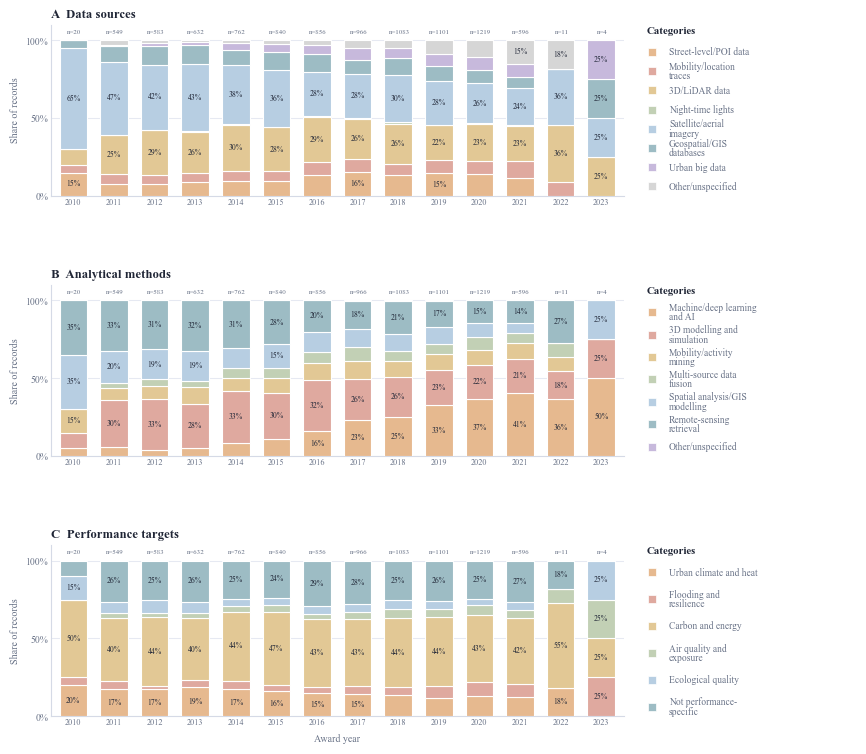

In [7]:
# ===== 7. Fig. 8: Annual Three-Panel Small-Multiple 100% Stacked Bars =====
# The three panels show data sources, analytical methods, and performance targets; the x-axis uses the complete 2010-2023 award_year range.

FIG4_COLORS = {
    "sage": "#C2D0B5",
    "blue_gray": "#9DBCC4",
    "soft_blue": "#B7CEE2",
    "ochre": "#E2C895",
    "muted_purple": "#C7B9DC",
    "muted_orange": "#E6B98F",
    "muted_red": "#DFA99F",
    "teal_gray": "#A9C7C7",
    "neutral_gray": "#D6D6D6",
}

FIG8_GLOBAL_PALETTE = [
    FIG4_COLORS["muted_orange"],
    FIG4_COLORS["muted_red"],
    FIG4_COLORS["ochre"],
    FIG4_COLORS["sage"],
    FIG4_COLORS["soft_blue"],
    FIG4_COLORS["blue_gray"],
    FIG4_COLORS["muted_purple"],
    FIG4_COLORS["neutral_gray"],
]

def first_n_palette(categories):
    categories = list(categories)
    if len(categories) > len(FIG8_GLOBAL_PALETTE):
        raise ValueError(f"Fig. 8 palette has {len(FIG8_GLOBAL_PALETTE)} colors for {len(categories)} categories.")
    return OrderedDict((category, FIG8_GLOBAL_PALETTE[idx]) for idx, category in enumerate(categories))


FIG8_DATA_COLORS = first_n_palette(list(DATA_SOURCE_SPECS))
FIG8_METHOD_COLORS = first_n_palette(list(METHOD_SPECS))
FIG8_PERFORMANCE_COLORS = first_n_palette(PERFORMANCE_ORDER)

PANEL_CONFIGS = [
    ("A", "Data sources", list(DATA_SOURCE_SPECS), FIG8_DATA_COLORS),
    ("B", "Analytical methods", list(METHOD_SPECS), FIG8_METHOD_COLORS),
    ("C", "Performance targets", PERFORMANCE_ORDER, FIG8_PERFORMANCE_COLORS),
]
FIG8_YEAR_AXIS = YEAR_AXIS.copy()
FIG8_N = int(year_counts.reindex(FIG8_YEAR_AXIS).sum())
if FIG8_N != len(classified):
    raise ValueError(f"Fig. 8 annual-axis count {FIG8_N} does not match master-data N={len(classified)}.")

fig8 = plt.figure(figsize=(8.8, 7.6), facecolor=TOKENS["white"])
grid = fig8.add_gridspec(
    nrows=3,
    ncols=2,
    width_ratios=[5.2, 1.9],
    height_ratios=[1, 1, 1],
    hspace=0.52,
    wspace=0.06,
)

x_positions = np.arange(len(FIG8_YEAR_AXIS))

for row_index, (panel_letter, dimension, categories, colors) in enumerate(PANEL_CONFIGS):
    ax = fig8.add_subplot(grid[row_index, 0])
    legend_ax = fig8.add_subplot(grid[row_index, 1])
    legend_ax.axis("off")

    panel_data = annual_table.loc[annual_table["dimension"].eq(dimension)].copy()
    bottom = np.zeros(len(FIG8_YEAR_AXIS), dtype=float)

    for category in categories:
        values = (
            panel_data.loc[panel_data["category"].eq(category)]
            .set_index("award_year")
            .reindex(FIG8_YEAR_AXIS)["percent_within_year"]
            .fillna(0)
            .to_numpy(dtype=float)
        )
        ax.bar(
            x_positions,
            values,
            bottom=bottom,
            width=0.68,
            color=colors[category],
            edgecolor=TOKENS["white"],
            linewidth=0.8,
            zorder=3,
        )

        # Place percentages only on wide enough segments to avoid text overlap in small segments.
        for x, value, base in zip(x_positions, values, bottom):
            if value >= 14:
                ax.text(
                    x,
                    base + value / 2,
                    f"{value:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=5.6,
                    color=TOKENS["ink"],
                    zorder=4,
                )
        bottom += values

    # Place annual sample sizes above the bars; Fig. 8 uses the complete 2010-2023 award_year axis.
    for x, year in zip(x_positions, FIG8_YEAR_AXIS):
        n_value = int(year_counts.loc[year])
        ax.text(x, 103.5, f"n={n_value}", ha="center", va="bottom", fontsize=5.0, color=TOKENS["muted"])

    ax.set_title(f"{panel_letter}  {dimension}", loc="left", fontsize=9.2, fontweight="semibold", color=TOKENS["ink"], pad=5)
    ax.set_xlim(-0.55, len(FIG8_YEAR_AXIS) - 0.45)
    ax.set_ylim(0, 110)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(FIG8_YEAR_AXIS, fontsize=5.9)
    ax.set_yticks([0, 50, 100])
    format_percent_axis(ax, axis="y")
    ax.grid(axis="y", color=TOKENS["grid"], linewidth=0.75, zorder=0)
    ax.grid(axis="x", visible=False)
    ax.spines["left"].set_color(TOKENS["axis"])
    ax.spines["bottom"].set_color(TOKENS["axis"])
    ax.tick_params(axis="both", length=0, colors=TOKENS["muted"], pad=2)
    ax.set_ylabel("Share of records", fontsize=7.2, color=TOKENS["muted"])
    if row_index == 2:
        ax.set_xlabel("Award year", fontsize=7.2, color=TOKENS["muted"], labelpad=5)

    # Each panel uses a right-side legend stretched vertically to align legend height with the main plot.
    legend_ax.text(0.0, 0.99, "Categories", ha="left", va="top", fontsize=7.8, fontweight="semibold", color=TOKENS["ink"])
    legend_y_top = 0.84
    legend_y_bottom = 0.055
    step = (legend_y_top - legend_y_bottom) / max(len(categories) - 1, 1)
    for idx, category in enumerate(categories):
        y = legend_y_top - idx * step
        legend_ax.scatter(0.025, y, s=34, marker="s", color=colors[category], edgecolor=TOKENS["white"], linewidth=0.5)
        legend_ax.text(0.105, y, wrap_label(category, width=22), ha="left", va="center", fontsize=6.85, color=TOKENS["muted"], linespacing=0.93)
    legend_ax.set_xlim(0, 1)
    legend_ax.set_ylim(0, 1)

fig8.subplots_adjust(left=0.07, right=0.985, top=0.975, bottom=0.065)

save_publication_figure(fig8, FIG8_BASE)

print("Exported Fig. 8 files:")
for suffix in ["svg", "pdf", "tiff", "png"]:
    path = Path(f"{FIG8_BASE}.{suffix}")
    print(f"- {path.name}: {path.stat().st_size / 1024:.1f} KB")

plt.show()


In [ ]:
# ===== 8. Fig. 9: Scale-Heterogeneity Horizontal 100% Stacked Bars =====
# The two panels compare scale-specific data-source and performance-target composition; scale n values sum to the new master-table N=9222.

FIG9_GLOBAL_PALETTE = [
    "#E6B98F",
    "#DFA99F",
    "#E2C895",
    "#C2D0B5",
    "#B7CEE2",
    "#9DBCC4",
    "#C7B9DC",
    "#D6D6D6",
]


def fig9_first_n_palette(categories):
    """Use the first N colors from the same global palette order for each Fig. 9 panel."""
    categories = list(categories)
    if len(categories) > len(FIG9_GLOBAL_PALETTE):
        raise ValueError(f"Fig. 9 palette has {len(FIG9_GLOBAL_PALETTE)} colors for {len(categories)} categories.")
    return OrderedDict((category, FIG9_GLOBAL_PALETTE[idx]) for idx, category in enumerate(categories))


FIG9_DATA_COLORS = fig9_first_n_palette(list(DATA_SOURCE_SPECS))
FIG9_PERFORMANCE_COLORS = fig9_first_n_palette(PERFORMANCE_ORDER)

fig9, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8.3, 5.55),
    sharey=True,
    facecolor=TOKENS["white"],
    gridspec_kw={"width_ratios": [1.08, 1.0], "wspace": 0.16},
)

H_PANEL_CONFIGS = [
    (axes[0], "Data sources", list(DATA_SOURCE_SPECS), FIG9_DATA_COLORS),
    (axes[1], "Performance targets", PERFORMANCE_ORDER, FIG9_PERFORMANCE_COLORS),
]

y_positions = np.arange(len(SCALE_ORDER))

for ax, dimension, categories, colors in H_PANEL_CONFIGS:
    panel_data = scale_table.loc[scale_table["dimension"].eq(dimension)].copy()
    left = np.zeros(len(SCALE_ORDER), dtype=float)

    for category in categories:
        values = (
            panel_data.loc[panel_data["category"].eq(category)]
            .set_index("scale")
            .reindex(SCALE_ORDER)["percent_within_scale"]
            .fillna(0)
            .to_numpy(dtype=float)
        )
        ax.barh(
            y_positions,
            values,
            left=left,
            height=0.66,
            color=colors[category],
            edgecolor=TOKENS["white"],
            linewidth=0.8,
            zorder=3,
        )
        for y, value, base in zip(y_positions, values, left):
            if value >= 18:
                ax.text(
                    base + value / 2,
                    y,
                    f"{value:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=5.8,
                    color=TOKENS["ink"],
                    zorder=4,
                )
        left += values

    for y, scale in zip(y_positions, SCALE_ORDER):
        n_value = int(scale_counts.loc[scale])
        label_x = 101 if n_value else 2
        ax.text(label_x, y, f"n={n_value}", ha="left", va="center", fontsize=5.8, color=TOKENS["muted"])

    ax.set_xlim(0, 110)
    ax.set_xticks([0, 50, 100])
    format_percent_axis(ax, axis="x")
    ax.grid(axis="x", color=TOKENS["grid"], linewidth=0.75, zorder=0)
    ax.grid(axis="y", visible=False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(TOKENS["axis"])
    ax.tick_params(axis="both", length=0, colors=TOKENS["muted"], pad=2)
    ax.set_xlabel("Share within scale", fontsize=7.2, color=TOKENS["muted"], labelpad=5)

axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(SCALE_ORDER, fontsize=6.8, color=TOKENS["ink"])
axes[0].invert_yaxis()
axes[1].tick_params(axis="y", labelleft=False)

# Place each legend below its panel; manual layout keeps color swatches strictly aligned across each row.
def add_two_row_axis_legend(ax, categories, colors):
    legend_ncol = int(np.ceil(len(categories) / 2))
    rows = [categories[:legend_ncol], categories[legend_ncol:]]
    row_ys = [-0.130, -0.215]
    col_xs = np.linspace(0.000, 0.77 if legend_ncol == 4 else 0.70, legend_ncol)
    for row_index, row_categories in enumerate(rows):
        y = row_ys[row_index]
        for col_index, category in enumerate(row_categories):
            x = col_xs[col_index]
            ax.add_patch(Rectangle(
                (x, y - 0.014),
                0.030,
                0.028,
                transform=ax.transAxes,
                facecolor=colors[category],
                edgecolor=TOKENS["white"],
                linewidth=0.45,
                clip_on=False,
                zorder=5,
            ))
            ax.text(
                x + 0.038,
                y,
                wrap_label(category, width=17),
                transform=ax.transAxes,
                ha="left",
                va="center",
                fontsize=6.9,
                color=TOKENS["muted"],
                linespacing=0.82,
                clip_on=False,
                zorder=5,
            )


for ax, (_, _, categories, colors) in zip(axes, H_PANEL_CONFIGS):
    add_two_row_axis_legend(ax, categories, colors)

# Top titles are omitted for the final figure layout.
fig9.subplots_adjust(left=0.16, right=0.985, top=0.985, bottom=0.190)

save_publication_figure(fig9, FIG9_BASE)

print("Exported Fig. 9 files:")
for suffix in ["svg", "pdf", "tiff", "png"]:
    path = Path(f"{FIG9_BASE}.{suffix}")
    print(f"- {path.name}: {path.stat().st_size / 1024:.1f} KB")

plt.show()


In [ ]:
# ===== 9. Automatically Generate a Results-Paragraph Draft =====
# The log draft is written in English for manuscript writing; visible figure text remains entirely English.


def pct_text(numerator, denominator):
    """Convert a count into percentage text for the results draft."""
    if denominator == 0:
        return "0.0%"
    return f"{numerator / denominator * 100:.1f}%"


def top_categories(series, top_n=3):
    """Return the top N primary-category counts with stable ordering under the preset order."""
    counts = series.value_counts()
    return counts.head(top_n)


def describe_top(series, total=None, top_n=3):
    """Generate compact descriptions in the form category n (%)."""
    if total is None:
        total = len(series)
    parts = []
    for category, count in top_categories(series, top_n=top_n).items():
        parts.append(f"{category} {int(count)} records ({pct_text(int(count), total)})")
    return ", ".join(parts)


def top_within_subset(mask, column):
    """Find the leading category for one dimension within a subset."""
    subset = classified.loc[mask, column]
    if subset.empty:
        return "no records", 0, 0.0
    counts = subset.value_counts()
    category = counts.index[0]
    count = int(counts.iloc[0])
    return category, count, count / len(subset) * 100


def era_summary(years, column):
    """Extract the leading category for a specified year set for early/late trend comparison."""
    mask = classified["award_year_num"].isin(years)
    category, count, percent = top_within_subset(mask, column)
    return category, count, percent, int(mask.sum())


def format_year_span(years):
    """Format a consecutive list of years as a range for the log."""
    years = list(years)
    return f"{min(years)}-{max(years)}"


def scale_dominance_lines():
    """Describe the leading data-source and performance-target categories for each scale."""
    lines = []
    for scale in SCALE_ORDER:
        mask = classified["primary_scale"].eq(scale)
        n_scale = int(mask.sum())
        if n_scale == 0:
            lines.append(f"- {scale}: 0 records.")
            continue
        data_cat, data_n, data_pct = top_within_subset(mask, "primary_data_source")
        perf_cat, perf_n, perf_pct = top_within_subset(mask, "primary_performance")
        lines.append(
            f"- {scale}: n={n_scale}; data sources are led by {data_cat} ({data_n} records, {data_pct:.1f}%), "
            f"and performance targets are led by {perf_cat} ({perf_n} records, {perf_pct:.1f}%)."
        )
    return "\n".join(lines)


early_years = FIG8_YEAR_AXIS[:4]
late_years = FIG8_YEAR_AXIS[-4:]
source_early = era_summary(early_years, "primary_data_source")
source_late = era_summary(late_years, "primary_data_source")
method_early = era_summary(early_years, "primary_method")
method_late = era_summary(late_years, "primary_method")
perf_early = era_summary(early_years, "primary_performance")
perf_late = era_summary(late_years, "primary_performance")

specified_perf = classified.loc[classified["primary_performance"].ne("Not performance-specific"), "primary_performance"]

log_text = f"""# 09 Annual Technology Change and Scale Heterogeneity: Methods and Results Draft

## Data and Scope

- Input data: `data/{MAIN_DATA_FILENAME}` with N={len(classified)} records after deduplication and screening.
- Keyword table: `data/{KEYWORD_TABLE_FILENAME}` with {len(keyword_table)} terms; annual technology-change and performance classification use only method/performance terms from this table and matched terms from the master dataset.
- Fig. 8 uses the complete {YEAR_START}-{YEAR_END} `award_year` axis, covering {FIG8_N} records; 2022 has {int(year_counts.loc[2022])} records and 2023 has {int(year_counts.loc[2023])} records, retained as observed.
- Fig. 9 scale heterogeneity is based on all records in the same new master table, N={FIG9_N}; the n values for scale labels sum to this denominator.
- Structured place-field availability: `knowledge_prod_place`, `research_object_place`, and `beneficiary_city` have non-null counts of {place_non_null['knowledge_prod_place']}, {place_non_null['research_object_place']}, and {place_non_null['beneficiary_city']}, respectively. Therefore, this section does not conduct geocoded place analysis and uses only text cues to identify analytical scale.

## Classification Method

- Annual technology change uses three primary dimensions: data sources, analytical methods, and performance targets. Each record is assigned to one primary category per dimension so that the denominator of the 100% stacked bars remains annual record count rather than multiple-hit count.
- Data sources and analytical methods come from `matched_method_terms` and are validated against method terms in the new keyword table. When a record matches multiple terms, more specific data streams or technical routes are prioritized, such as street-level/POI, mobility traces, 3D/LiDAR, and night-time lights before broad urban big data or GIS.
- Performance targets come from `matched_performance_terms` and are validated against performance_environment terms in the new keyword table. Records without clear performance terms are assigned to `Not performance-specific`; records with multiple performance terms are checked first for heat, flood/resilience, carbon/energy, air/exposure, and ecology, then the broad climate term is used as a fallback.
- Scale classification uses text cues from `matched_object_terms`, `project_title`, `abstract_text`, and `keywords_raw`, identifying primary scale in the order Building, Street, Block, Urban agglomeration, Regional, City, and Not specified. Multi-scale projects are collapsed to the most specific visible scale.

## Main Annual Technology-Change Trends

- Overall Top 3 data sources: {describe_top(classified['primary_data_source'])}.
- Overall Top 3 analytical methods: {describe_top(classified['primary_method'])}.
- Among performance targets, `Not performance-specific` accounts for {int((classified['primary_performance'] == 'Not performance-specific').sum())} records ({pct_text(int((classified['primary_performance'] == 'Not performance-specific').sum()), len(classified))}); among records with explicit performance targets, the Top 3 are: {describe_top(specified_perf, total=len(specified_perf))}.
- In {format_year_span(early_years)}, the leading data-source category is {source_early[0]} ({source_early[1]}/{source_early[3]}, {source_early[2]:.1f}%); in {format_year_span(late_years)}, it is {source_late[0]} ({source_late[1]}/{source_late[3]}, {source_late[2]:.1f}%).
- In {format_year_span(early_years)}, the leading analytical-method category is {method_early[0]} ({method_early[1]}/{method_early[3]}, {method_early[2]:.1f}%); in {format_year_span(late_years)}, it is {method_late[0]} ({method_late[1]}/{method_late[3]}, {method_late[2]:.1f}%).
- In {format_year_span(early_years)}, the leading performance-target category is {perf_early[0]} ({perf_early[1]}/{perf_early[3]}, {perf_early[2]:.1f}%); in {format_year_span(late_years)}, it is {perf_late[0]} ({perf_late[1]}/{perf_late[3]}, {perf_late[2]:.1f}%).

## Main Scale-Heterogeneity Trends

{scale_dominance_lines()}

## Limitations

- This section is text-rule coding at the project-record level, not manual full-text coding of papers; categories should be understood as reproducible review signals rather than a final disciplinary ontology.
- A project may cover multiple data sources, methods, performance targets, or spatial scales at the same time. For 100% charts, this notebook compresses each record to one primary category, which underestimates multi-source, multi-method, and multi-scale co-occurrence.
- Place fields are empty, so research location, knowledge-production location, and beneficiary city cannot be distinguished; scale heterogeneity only represents analytical scales visible in text.
- Fig. 8 and the annual table both use the complete {YEAR_START}-{YEAR_END} annual axis; low-sample years are shown as observed and are not trimmed to an early subrange.

## Output Files

- Fig. 8: `output/figures/Fig8_annual_method_changes.svg/pdf/tiff/png`
- Fig. 9: `output/figures/Fig9_scale_heterogeneity.svg/pdf/tiff/png`
- Tables: `output/tables/09_annual_method_changes.csv`; `output/tables/09_scale_heterogeneity.csv`
"""

LOG_PATH.write_text(log_text, encoding="utf-8")
print(f"Saved log: {LOG_PATH}")
display(Markdown(log_text))


In [ ]:

# ===== 10. Output Completeness Check =====
# Confirm that the figures, tables, and log assigned to this notebook have been generated and are non-empty.

expected_outputs = [
    ANNUAL_TABLE_PATH,
    SCALE_TABLE_PATH,
    LOG_PATH,
    *[Path(f"{FIG8_BASE}.{suffix}") for suffix in ["svg", "pdf", "tiff", "png"]],
    *[Path(f"{FIG9_BASE}.{suffix}") for suffix in ["svg", "pdf", "tiff", "png"]],
]

missing_or_empty = [path for path in expected_outputs if (not path.exists()) or path.stat().st_size == 0]
if missing_or_empty:
    raise FileNotFoundError(f"The following outputs are missing or empty: {missing_or_empty}")

for path in expected_outputs:
    print(f"OK {path.relative_to(ROOT)} ({path.stat().st_size / 1024:.1f} KB)")
